# 1.Importing necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio

In [2]:

pio.renderers.default = "png"

# 2.Importing the Dataset

In [3]:
df = pd.read_csv("Zomato_Chennai_Dataset.csv")
df

,Zomato URL,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,https://www.zomato.com/chennai/yaa-mohaideen-b...,Yaa Mohaideen Briyani,"336 & 338, Main Road, Pallavaram, Chennai",Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,https://www.zomato.com/chennai/sukkubhai-biriy...,Sukkubhai Biriyani,"New 14, Old 11/3Q, Railway Station Road, MKN ...",Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,https://www.zomato.com/chennai/ss-hyderabad-bi...,SS Hyderabad Biryani,"98/339, Arcot Road, Opposite Gokulam Chit Fun...",Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,https://www.zomato.com/chennai/kfc-perambur,KFC,"10, Periyar Nagar, 70 Feet Road, Near Sheeba ...",Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,https://www.zomato.com/chennai/tasty-kitchen-p...,Tasty Kitchen,"135B, SRP Colony, Peravallur, Near Perambur, ...",Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"
...,...,...,...,...,...,...,...,...,...,...,...,...
12027,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Porur,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12028,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Kolathur,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12029,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Anna Nagar East,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12030,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Ramapuram,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"


# 3. dataset Info

In [4]:
df.shape

(12032, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12032 entries, 0 to 12031
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Zomato URL             12032 non-null  object 
 1   Name of Restaurant     12032 non-null  object 
 2   Address                12032 non-null  object 
 3   Location               12032 non-null  object 
 4   Cuisine                12032 non-null  object 
 5   Top Dishes             12032 non-null  object 
 6   Price for 2            12032 non-null  float64
 7   Dining Rating          6681 non-null   float64
 8   Dining Rating Count    11812 non-null  object 
 9   Delivery Rating        6181 non-null   float64
 10  Delivery Rating Count  11812 non-null  object 
 11  Features               12032 non-null  object 
dtypes: float64(3), object(9)
memory usage: 1.1+ MB


In [6]:
# Numerical data statistics
df.describe()

,Price for 2,Dining Rating,Delivery Rating
count,12032.000000,6681.000000,6181.000000
mean,397.611370,3.387756,3.805290
std,332.045938,0.558181,0.374213
min,40.000000,0.300000,0.300000
25%,200.000000,3.100000,3.600000
50%,300.000000,3.500000,3.900000
75%,450.000000,3.800000,4.000000
max,5000.000000,4.900000,4.700000


In [7]:
# Categorical data statistics
df.describe(include='object')

,Zomato URL,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Dining Rating Count,Delivery Rating Count,Features
count,12032,12032,12032,12032,12032,12032,11812,11812,12032
unique,12032,8369,10828,268,2423,2190,793,2281,1554
top,https://www.zomato.com/chennai/sardarji-kulfi-...,Amma Unavagam,Delivery Only,Porur,['South Indian'],Invalid,Does not offer Dining,Not enough Delivery Reviews,"['Home Delivery', 'Indoor Seating']"
freq,1,78,443,418,883,9641,2603,3379,2447


# 4. Cleaning the Dataset

***1. Removing unnecessary data***

In [8]:
# Dropping columns that are not useful for analysis
df.drop(['Zomato URL','Address'],axis=1,inplace=True)  # Dropping address since we have Location Column for Regional analysis
df

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",500.0,4.3,1500,4.3,9306,"['Home Delivery', 'Indoor Seating']"
1,Sukkubhai Biriyani,Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",1000.0,4.4,3059,4.1,39200,"['Home Delivery', 'Free Parking', 'Table booki..."
2,SS Hyderabad Biryani,Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",500.0,4.3,1361,4.4,10500,"['Home Delivery', 'Indoor Seating']"
3,KFC,Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],500.0,4.0,1101,4.0,11200,"['Home Delivery', 'Free Parking', 'Card Upon D..."
4,Tasty Kitchen,Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",450.0,4.2,617,4.1,22400,"['Home Delivery', 'Indoor Seating']"
...,...,...,...,...,...,...,...,...,...,...
12027,CK's Sandwiches,Porur,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12028,CK's Sandwiches,Kolathur,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12029,CK's Sandwiches,Anna Nagar East,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"
12030,CK's Sandwiches,Ramapuram,['Sandwich'],Invalid,350.0,NaN,NaN,NaN,NaN,"['Breakfast', 'Delivery Only']"


***2. Converting text data in count columns***

In [9]:
df["Dining Rating Count"].value_counts()

Dining Rating Count
Does not offer Dining        2603
Not enough Dining Reviews    2528
4                             339
5                             271
6                             248
                             ... 
1267                            1
1302                            1
5073                            1
1739                            1
814                             1
Name: count, Length: 793, dtype: int64

In [10]:
df["Delivery Rating Count"].value_counts()

Delivery Rating Count
Not enough Delivery Reviews    3379
Does not offer Delivery        2252
27                               34
40                               30
32                               30
                               ... 
4787                              1
3159                              1
1355                              1
1948                              1
1897                              1
Name: count, Length: 2281, dtype: int64

In [11]:
# Converting text data in those columns to 0
df["Dining Rating Count"] = df["Dining Rating Count"].replace(["Does not offer Dining","Not enough Dining Reviews"],0)
df["Delivery Rating Count"] = df["Delivery Rating Count"].replace(["Does not offer Delivery","Not enough Delivery Reviews"],0)

***3. Null values handling***

In [12]:
# Checking for null values
df.isnull().sum()

Name of Restaurant          0
Location                    0
Cuisine                     0
Top Dishes                  0
Price for 2                 0
Dining Rating            5351
Dining Rating Count       220
Delivery Rating          5851
Delivery Rating Count     220
Features                    0
dtype: int64

In [13]:
# filling 0 for null values in count columns as there are no Rating counts
df["Dining Rating Count"] = df["Dining Rating Count"].fillna(0)
df["Delivery Rating Count"] = df["Delivery Rating Count"].fillna(0)

In [14]:
# Dining and Delivery rating columns have a lot of null values removing them causes huge data loss 
# So we are imputing the null values using median by grouping based on region

dining_median = df.groupby('Location')['Dining Rating'].transform('median')
delivery_median = df.groupby('Location')['Delivery Rating'].transform('median')

# Fill missing values with their neighborhood's median score
df['Dining Rating'] = df['Dining Rating'].fillna(dining_median)
df['Delivery Rating'] = df['Delivery Rating'].fillna(delivery_median)

In [15]:
# If a neighborhood has zero rated restaurants, fill any remaining nulls with the global city median
df['Dining Rating'] = df['Dining Rating'].fillna(df['Dining Rating'].median())
df['Delivery Rating'] = df['Delivery Rating'].fillna(df['Delivery Rating'].median())

In [16]:
df.isnull().sum()

Name of Restaurant       0
Location                 0
Cuisine                  0
Top Dishes               0
Price for 2              0
Dining Rating            0
Dining Rating Count      0
Delivery Rating          0
Delivery Rating Count    0
Features                 0
dtype: int64

***4. Converting the DataTypes of numerical columns to numeric datatype***

In [17]:
df["Dining Rating Count"] = df["Dining Rating Count"].astype('int64')
df["Delivery Rating Count"] = df["Delivery Rating Count"].astype('int64')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12032 entries, 0 to 12031
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Name of Restaurant     12032 non-null  object 
 1   Location               12032 non-null  object 
 2   Cuisine                12032 non-null  object 
 3   Top Dishes             12032 non-null  object 
 4   Price for 2            12032 non-null  float64
 5   Dining Rating          12032 non-null  float64
 6   Dining Rating Count    12032 non-null  int64  
 7   Delivery Rating        12032 non-null  float64
 8   Delivery Rating Count  12032 non-null  int64  
 9   Features               12032 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 940.1+ KB


***5. Working with Location Column***

In [19]:
# Standardizing the locations
# Strip any accidental leading or trailing whitespaces from the strings
df['Location'] = df['Location'].str.strip()

In [20]:
#Group East/West split zones into single unified neighborhoods
df['Location'] = df['Location'].replace(["Anna Nagar East","Anna Nagar West"],'Anna Nagar')
df['Location'] = df['Location'].replace(['K.K. Nagar East', 'K.K. Nagar West', 'K.K. Nagar'], 'K.K. Nagar')


In [21]:
# Confirmation of LOcation Changes
(df['Location'] == 'K.K. Nagar').sum()

np.int64(110)

In [22]:
print("New Top 15 Locations in Chennai:")
print(df['Location'].value_counts().head(15))

New Top 15 Locations in Chennai:
Location
Anna Nagar      524
Porur           418
Velachery       372
Ambattur        334
T. Nagar        315
Perungudi       288
Perambur        275
Medavakkam      271
Tambaram        258
Ramapuram       248
Nungambakkam    248
Thuraipakkam    237
Mogappair       218
Selaiyur        218
Madipakkam      202
Name: count, dtype: int64


***6. Working with Cuisine column***

In [23]:
# Clean the brackets and single quotes out of the text
df['Cuisine'] = df['Cuisine'].str.replace(r"[\[\]']", "", regex=True)

In [24]:
#Strip any accidental leading or trailing white spaces that remain inside the comma list
df['Cuisine'] = df['Cuisine'].str.strip()

In [25]:
#cleaned cuisine Column
print("Cleaned Cuisine Samples:")
print(df['Cuisine'].head(10))

Cleaned Cuisine Samples:
0                                              Biryani
1    Biryani,  North Indian,  Mughlai,  Desserts,  ...
2           Biryani,  North Indian,  Chinese,  Arabian
3         Burger,  Fast Food,  Finger Food,  Beverages
4    Chinese,  Biryani,  North Indian,  Chettinad, ...
5                South Indian,  North Indian,  Chinese
6                                              Biryani
7                                     Cafe,  Fast Food
8    Arabian,  Chinese,  North Indian,  Lebanese,  ...
9    South Indian,  North Indian,  Chinese,  Chetti...
Name: Cuisine, dtype: object


***7. Working on Top dishes and Features columns***

In [26]:
#Strip brackets and quotes from Top Dishes and Features columns
df['Top Dishes'] = df['Top Dishes'].str.replace(r"[\[\]']", "", regex=True).str.strip()
df['Features'] = df['Features'].str.replace(r"[\[\]']", "", regex=True).str.strip()

In [27]:
# Checking the Data Frame
df.head(50)

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,Biryani,"Bread Halwa, Chicken 65, Mutton Biryani, Ch...",500.0,4.3,1500,4.3,9306,"Home Delivery, Indoor Seating"
1,Sukkubhai Biriyani,Alandur,"Biryani, North Indian, Mughlai, Desserts, ...","Beef Biryani, Beef Fry, Paratha, Paya, Bri...",1000.0,4.4,3059,4.1,39200,"Home Delivery, Free Parking, Table booking rec..."
2,SS Hyderabad Biryani,Kodambakkam,"Biryani, North Indian, Chinese, Arabian","Brinjal Curry, Tandoori Chicken, Chicken Gri...",500.0,4.3,1361,4.4,10500,"Home Delivery, Indoor Seating"
3,KFC,Perambur,"Burger, Fast Food, Finger Food, Beverages",Zinger Burger,500.0,4.0,1101,4.0,11200,"Home Delivery, Free Parking, Card Upon Deliver..."
4,Tasty Kitchen,Perambur,"Chinese, Biryani, North Indian, Chettinad, ...","Mutton Biryani, Chicken Rice, Tomato Rice, ...",450.0,4.2,617,4.1,22400,"Home Delivery, Indoor Seating"
5,Dine N Fun,Medavakkam,"South Indian, North Indian, Chinese","Chicken Grill, Shawarma, Naan, Chicken Butt...",450.0,4.1,567,3.8,24700,"Home Delivery, Indoor Seating"
6,Bai Veetu Kalyanam,Navallur,Biryani,"Bread Halwa, Mutton Biryani, Brinjal Gravy, ...",350.0,3.5,0,4.3,1061,Home Delivery
7,Cafe Arabica,Anna Nagar,"Cafe, Fast Food","Burgers, Pasta, Sandwich, Strawberry Mojito...",800.0,4.3,668,4.3,4320,"Breakfast, Home Delivery, Indoor Seating, Dess..."
8,Savoury Sea Shell,Anna Nagar,"Arabian, Chinese, North Indian, Lebanese, ...","Shawarma, Chicken Grill, Brownie, Sea Food,...",1400.0,4.2,2564,4.1,21700,"Home Delivery, Indoor Seating, Card Upon Deliv..."
9,Sangeetha Veg Restaurant,T. Nagar,"South Indian, North Indian, Chinese, Chetti...","Filtered Coffee, Chaat, Faluda, Masala Dosa...",800.0,4.4,1578,4.2,39600,"Breakfast, Home Delivery, Vegetarian Only, Ind..."


***8. Checking for duplicate records***

In [28]:
# Finding all the duplicate rows
df[df.duplicated()]

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
9103,Brownie Heaven,T. Nagar,"Bakery, Desserts, Beverages",Invalid,350.0,3.60,0,3.90,0,"Home Delivery, Indoor Seating, Desserts and Bakes"
9995,ibaco,Kanchipuram District,Ice Cream,Invalid,200.0,3.35,0,3.70,0,"Home Delivery, Vegetarian Only, Indoor Seating..."
10534,Cake Waves,Thiruvallur,"Bakery, Fast Food",Invalid,500.0,3.40,0,4.00,0,"Home Delivery, Indoor Seating, Desserts and Bakes"
11225,Pizza Square,Thiruvanmiyur,"Pizza, Fast Food",Invalid,300.0,3.30,0,3.90,0,"Home Delivery, Indoor Seating"
11361,Aavin Parlour,George Town,Ice Cream,Invalid,200.0,3.60,0,3.90,0,"Takeaway Only, Desserts and Bakes"
11390,The Cake Point,Mogappair,Bakery,Invalid,200.0,3.50,0,3.90,0,"Home Delivery, Indoor Seating, Desserts and Bakes"
11489,Parantha Pundit,Mogappair,"North Indian, Beverages",Invalid,200.0,3.50,0,3.90,0,Delivery Only
11496,Parantha Pundit,Kovalam,"North Indian, Beverages",Invalid,200.0,2.70,0,3.90,0,Delivery Only
11553,Leo Coffee,Mylapore,"Coffee, Tea, Beverages",Invalid,250.0,3.60,0,3.90,0,Home Delivery
11572,Leo Coffee,Anna Nagar,"Coffee, Tea, Beverages",Invalid,250.0,3.70,0,3.90,0,"Takeaway Only, Vegetarian Only"


In [29]:
# Dropping all the duplicate rows
df = df.drop_duplicates()

# 6. Copying the Cleaned Data to new DataFrame

In [30]:
zomato_df = df.copy()
zomato_df.head()

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,Biryani,"Bread Halwa, Chicken 65, Mutton Biryani, Ch...",500.0,4.3,1500,4.3,9306,"Home Delivery, Indoor Seating"
1,Sukkubhai Biriyani,Alandur,"Biryani, North Indian, Mughlai, Desserts, ...","Beef Biryani, Beef Fry, Paratha, Paya, Bri...",1000.0,4.4,3059,4.1,39200,"Home Delivery, Free Parking, Table booking rec..."
2,SS Hyderabad Biryani,Kodambakkam,"Biryani, North Indian, Chinese, Arabian","Brinjal Curry, Tandoori Chicken, Chicken Gri...",500.0,4.3,1361,4.4,10500,"Home Delivery, Indoor Seating"
3,KFC,Perambur,"Burger, Fast Food, Finger Food, Beverages",Zinger Burger,500.0,4.0,1101,4.0,11200,"Home Delivery, Free Parking, Card Upon Deliver..."
4,Tasty Kitchen,Perambur,"Chinese, Biryani, North Indian, Chettinad, ...","Mutton Biryani, Chicken Rice, Tomato Rice, ...",450.0,4.2,617,4.1,22400,"Home Delivery, Indoor Seating"


In [31]:
zomato_df.to_csv("Zomato_Chennai_Cleaned.csv",index=False)

# 7. Perfroming Exploratory Data Analysis

***Q1) How many restaurants are in Chennai for each type of cuisine?***

In [32]:
# Split the comma-separated cuisine string into lists, then explode into individual rows
exploded_cuisine = zomato_df['Cuisine'].str.split(', ').explode()

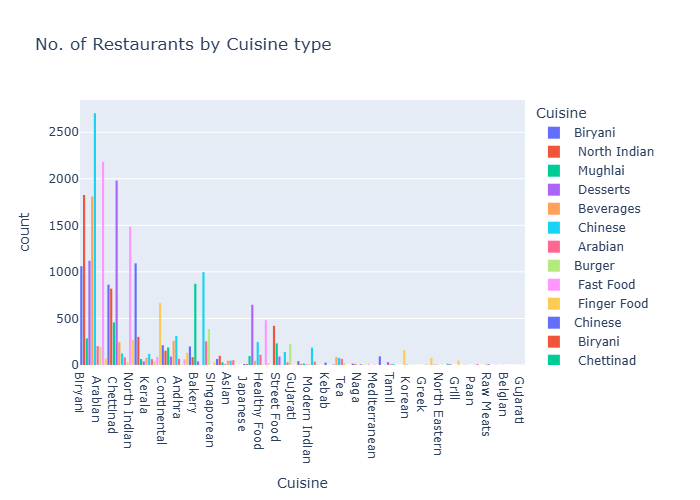

In [33]:
fig= px.histogram(exploded_cuisine, x='Cuisine', color='Cuisine', 
                  title= 'No. of Restaurants by Cuisine type',
                  labels={'CUISINE':'Cuisine'})
fig.show()

***Q2) Which locations in Chennai have the highest number of restaurants (Top 10)?***

In [34]:
location_counts = zomato_df['Location'].value_counts().reset_index()
location_counts.columns = ['Location', 'Total Restaurants']

#top 10 restaurant 
top_10_locations = location_counts.head(10)
top_10_locations

,Location,Total Restaurants
0,Anna Nagar,521
1,Porur,415
2,Velachery,372
3,Ambattur,328
4,T. Nagar,314
5,Perungudi,288
6,Perambur,275
7,Medavakkam,271
8,Tambaram,256
9,Ramapuram,248


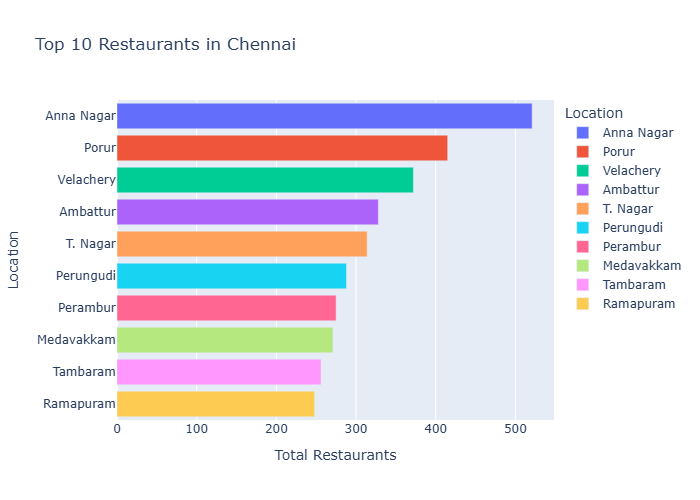

In [35]:
fig = px.bar(
    top_10_locations,
    x='Total Restaurants',
    y='Location',
    orientation='h',
    color='Location',
    title='Top 10 Restaurants in Chennai'
).update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

***Q3) Which are the Top 10 highest rated Chinese Restaurant in Chennai?***

In [36]:
chinese_df = zomato_df[zomato_df['Cuisine'].str.contains('Chinese')]
chinese_df.sort_values(by ='Dining Rating', ascending = False)
chinese_df[['Name of Restaurant', 'Location', 'Dining Rating', 'Dining Rating Count', 'Price for 2']].head(10)

,Name of Restaurant,Location,Dining Rating,Dining Rating Count,Price for 2
2,SS Hyderabad Biryani,Kodambakkam,4.3,1361,500.0
4,Tasty Kitchen,Perambur,4.2,617,450.0
5,Dine N Fun,Medavakkam,4.1,567,450.0
8,Savoury Sea Shell,Anna Nagar,4.2,2564,1400.0
9,Sangeetha Veg Restaurant,T. Nagar,4.4,1578,800.0
12,Hotel Al Buhari,Vadapalani,4.0,982,350.0
13,Dindigul Thalappakatti,Porur,4.3,770,900.0
14,Hotel Paramount,Kilpauk,4.3,1266,500.0
16,Arab Street,Ashok Nagar,4.1,1363,800.0
17,Abid's,Chetpet,4.2,742,1200.0


***Q4) Which places have the highest rated restaurant for each Cuisine Type in Chennai?***

In [37]:
sorted_df = zomato_df.sort_values(by=['Dining Rating', 'Delivery Rating'], ascending=[False, False])
highest_rated_cuisine_df = sorted_df.groupby('Cuisine').first().reset_index()
top_cuisines = zomato_df['Cuisine'].value_counts().head(15).index
final_highest_df = highest_rated_cuisine_df[highest_rated_cuisine_df['Cuisine'].isin(top_cuisines)]
final_highest_df[['Cuisine', 'Name of Restaurant', 'Location', 'Dining Rating','Delivery Rating']]

,Cuisine,Name of Restaurant,Location,Dining Rating,Delivery Rating
180,Bakery,Cakes and Berrys,Porur,4.0,4.40
189,"Bakery, Desserts",The Pastry Shop,"The Raintree, Teynampet",4.3,3.90
255,Beverages,Kalathi Rose Milk Shop,Mylapore,4.2,3.90
274,"Beverages, Fast Food",Milkshake And Co.,Besant Nagar,4.4,4.20
336,Biryani,Yaa Mohaideen Briyani,Pallavaram,4.3,4.30
365,"Biryani, Chinese",Anburaj Briyani & Fast Food,Alwarpet,3.8,4.00
728,Chinese,Golden Dragon - Taj Coromandel,"Taj Coromandel, Nungambakkam",4.4,3.90
1065,Fast Food,Fusilli Reasons,Kilpauk,4.7,4.40
1074,"Fast Food, Beverages",Food Affair,Virugambakkam,4.0,3.85
1274,Ice Cream,Bombay Kulfi,Adyar,4.9,4.30


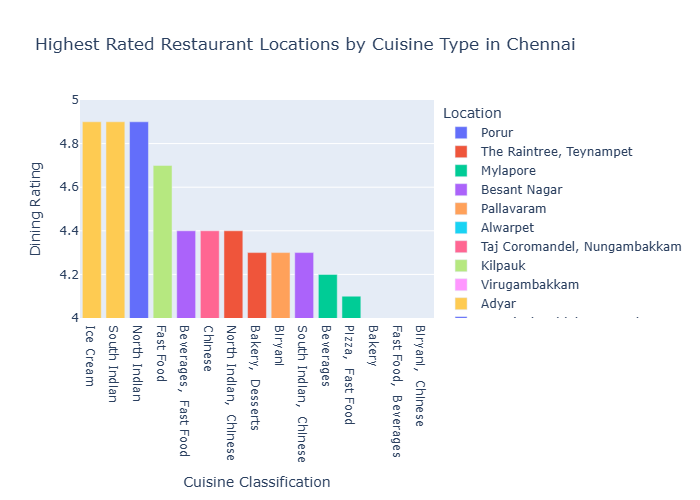

In [38]:
# Generate the standard visualization matching the Mumbai layout syntax
fig = px.bar(
    final_highest_df,
    x='Cuisine',
    y='Dining Rating',
    color='Location',
    title='Highest Rated Restaurant Locations by Cuisine Type in Chennai',
    hover_data=['Name of Restaurant', 'Price for 2']
).update_layout(
    xaxis_title='Cuisine Classification',
    yaxis_title='Dining Rating',
    yaxis=dict(range=[4.0, 5.0]),
    xaxis={'categoryorder': 'total descending'}
)

fig.show()

***Q5) What is the Avg Price Distibution of highest rated restaurant for each Cuisine Type in Chennai?***

In [39]:
sorted_df = zomato_df.sort_values(by=['Dining Rating', 'Dining Rating Count'], ascending=[False, False])
highest_rated_cuisine_df = sorted_df.groupby('Cuisine').first().reset_index()

In [40]:
highest_rated_cuisine_df['Price for 2'].describe()

count    2423.000000
mean      564.812216
std       496.400291
min        60.000000
25%       300.000000
50%       400.000000
75%       600.000000
max      4800.000000
Name: Price for 2, dtype: float64

In [41]:
highest_rated_df = zomato_df[zomato_df['Dining Rating']>=4.5]
avg_price_df = highest_rated_df.groupby(by=["Location","Cuisine"])["Price for 2"].mean().reset_index()
avg_price_df.head(10)

,Location,Cuisine,Price for 2
0,Adyar,"Chinese, Thai",800.0
1,Adyar,Ice Cream,200.0
2,Adyar,"North Indian, Chettinad, Mughlai, Desserts,...",1800.0
3,Adyar,South Indian,500.0
4,Alwarpet,"Desserts, Ice Cream",350.0
5,Alwarpet,"Fast Food, Desserts, Beverages",150.0
6,Alwarpet,Middle Eastern,700.0
7,Alwarpet,"Singaporean, American, European, Continenta...",1800.0
8,Alwarpet,South Indian,250.0
9,Alwarpet,Thai,2000.0


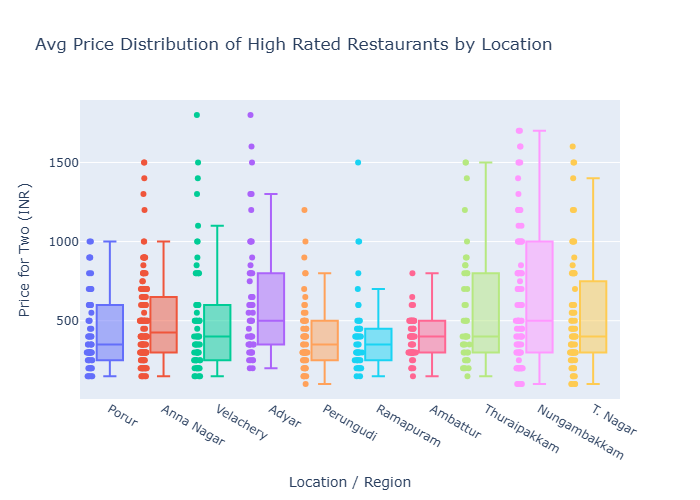

In [58]:
top_10_locations = highest_rated_cuisine_df['Location'].value_counts().head(10).index
filtered_plot_df = highest_rated_cuisine_df[highest_rated_cuisine_df['Location'].isin(top_10_locations)]

fig = px.box(
    filtered_plot_df,
    x='Location',
    y='Price for 2',
    title='Avg Price Distribution of High Rated Restaurants by Location',
    color='Location',  # Colors each neighborhood uniquely
    points='all'       # Shows individual restaurant dots clearly next to the box
).update_layout(
    xaxis_title='Location / Region',
    yaxis_title='Price for Two (INR)',
    showlegend=False  # Removes the giant side legend since names are already on the X-axis
)
fig.show()

***Q6) Which areas have a large number of Chinese Restaurant Market?***

In [43]:
chinese_df = zomato_df[zomato_df["Cuisine"].str.contains("Chinese")]
chinese_df

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
2,SS Hyderabad Biryani,Kodambakkam,"Biryani, North Indian, Chinese, Arabian","Brinjal Curry, Tandoori Chicken, Chicken Gri...",500.0,4.3,1361,4.4,10500,"Home Delivery, Indoor Seating"
4,Tasty Kitchen,Perambur,"Chinese, Biryani, North Indian, Chettinad, ...","Mutton Biryani, Chicken Rice, Tomato Rice, ...",450.0,4.2,617,4.1,22400,"Home Delivery, Indoor Seating"
5,Dine N Fun,Medavakkam,"South Indian, North Indian, Chinese","Chicken Grill, Shawarma, Naan, Chicken Butt...",450.0,4.1,567,3.8,24700,"Home Delivery, Indoor Seating"
8,Savoury Sea Shell,Anna Nagar,"Arabian, Chinese, North Indian, Lebanese, ...","Shawarma, Chicken Grill, Brownie, Sea Food,...",1400.0,4.2,2564,4.1,21700,"Home Delivery, Indoor Seating, Card Upon Deliv..."
9,Sangeetha Veg Restaurant,T. Nagar,"South Indian, North Indian, Chinese, Chetti...","Filtered Coffee, Chaat, Faluda, Masala Dosa...",800.0,4.4,1578,4.2,39600,"Breakfast, Home Delivery, Vegetarian Only, Ind..."
...,...,...,...,...,...,...,...,...,...,...
12014,Bowl Bazaar,Adyar,"North Indian, South Indian, Chinese, Biryani",Invalid,500.0,3.7,0,3.9,0,Delivery Only
12015,Bowl Bazaar,Medavakkam,"North Indian, South Indian, Chinese, Biryani",Invalid,500.0,3.4,0,3.8,0,Delivery Only
12016,Bowl Bazaar,Perungudi,"North Indian, South Indian, Chinese",Invalid,400.0,3.5,0,3.7,0,Delivery Only
12017,Bowl Bazaar,Medavakkam,"North Indian, South Indian, Chinese",Invalid,400.0,3.4,0,3.8,0,Delivery Only


In [44]:
chinese_rest_df = chinese_df.groupby(by='Location').agg({'Name of Restaurant':'count','Price for 2':'mean'}).rename(columns={'Name of Restaurant':'COUNT OF RESTAURANTS','Price for 2':'PRICE'}).reset_index()
chinese_rest_df = chinese_rest_df.sort_values('COUNT OF RESTAURANTS',ascending=False).head(25)
chinese_rest_df

,Location,COUNT OF RESTAURANTS,PRICE
12,Anna Nagar,154,508.766234
143,Porur,131,409.541985
7,Ambattur,115,375.217391
199,Velachery,102,488.235294
138,Perambur,99,413.636364
139,Perungudi,93,445.698925
169,T. Nagar,90,491.111111
108,Medavakkam,89,464.606742
151,Ramapuram,86,411.511628
164,Sholinganallur,75,380.000000


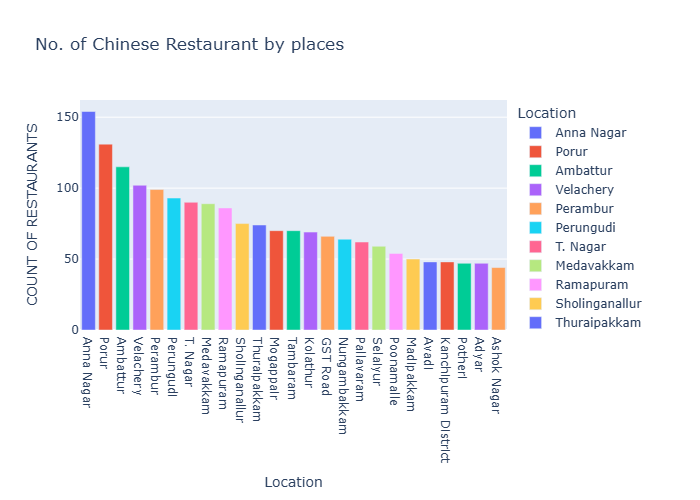

In [45]:
fig = px.bar(chinese_rest_df, x='Location', y='COUNT OF RESTAURANTS', color='Location', title= 'No. of Chinese Restaurant by places')
fig.show()

***Q7) Which areas have a large number of Briyani Restaurant Market?***

In [46]:
biryani_df = zomato_df[zomato_df["Cuisine"].str.contains("Biryani")]
biryani_df

,Name of Restaurant,Location,Cuisine,Top Dishes,Price for 2,Dining Rating,Dining Rating Count,Delivery Rating,Delivery Rating Count,Features
0,Yaa Mohaideen Briyani,Pallavaram,Biryani,"Bread Halwa, Chicken 65, Mutton Biryani, Ch...",500.0,4.3,1500,4.3,9306,"Home Delivery, Indoor Seating"
1,Sukkubhai Biriyani,Alandur,"Biryani, North Indian, Mughlai, Desserts, ...","Beef Biryani, Beef Fry, Paratha, Paya, Bri...",1000.0,4.4,3059,4.1,39200,"Home Delivery, Free Parking, Table booking rec..."
2,SS Hyderabad Biryani,Kodambakkam,"Biryani, North Indian, Chinese, Arabian","Brinjal Curry, Tandoori Chicken, Chicken Gri...",500.0,4.3,1361,4.4,10500,"Home Delivery, Indoor Seating"
4,Tasty Kitchen,Perambur,"Chinese, Biryani, North Indian, Chettinad, ...","Mutton Biryani, Chicken Rice, Tomato Rice, ...",450.0,4.2,617,4.1,22400,"Home Delivery, Indoor Seating"
6,Bai Veetu Kalyanam,Navallur,Biryani,"Bread Halwa, Mutton Biryani, Brinjal Gravy, ...",350.0,3.5,0,4.3,1061,Home Delivery
...,...,...,...,...,...,...,...,...,...,...
12011,Bowl Bazaar,Anna Nagar,"North Indian, South Indian, Chinese, Biryani",Invalid,500.0,3.7,0,3.9,0,Delivery Only
12012,Bowl Bazaar,Ashok Nagar,"North Indian, South Indian, Chinese, Biryani",Invalid,500.0,3.5,0,3.9,0,Delivery Only
12013,Bowl Bazaar,Perungudi,"North Indian, South Indian, Chinese, Biryani",Invalid,500.0,3.5,0,3.7,0,Delivery Only
12014,Bowl Bazaar,Adyar,"North Indian, South Indian, Chinese, Biryani",Invalid,500.0,3.7,0,3.9,0,Delivery Only


In [47]:
biryani_rest_df = biryani_df.groupby(by='Location').agg({'Name of Restaurant':'count','Price for 2':'mean'}).rename(columns={'Name of Restaurant':'COUNT OF RESTAURANTS','Price for 2':'PRICE'}).reset_index()
biryani_rest_df = biryani_rest_df.sort_values('COUNT OF RESTAURANTS',ascending=False).head(25)
biryani_rest_df

,Location,COUNT OF RESTAURANTS,PRICE
8,Anna Nagar,72,504.861111
82,Porur,64,397.656250
5,Ambattur,57,406.140351
79,Perungudi,55,440.909091
119,Velachery,54,461.111111
103,Tambaram,52,422.115385
102,T. Nagar,52,444.230769
78,Perambur,50,424.000000
56,Medavakkam,47,476.595745
111,Thuraipakkam,46,465.217391


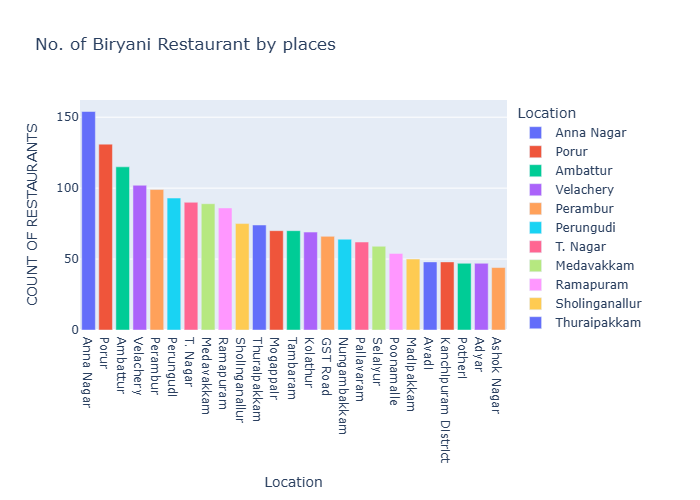

In [48]:
fig = px.bar(chinese_rest_df, x='Location', y='COUNT OF RESTAURANTS', color='Location', title= 'No. of Biryani Restaurant by places')
fig.show()

***Q8) Is there a relation between Price and Rating by each Cuisine Type?***

In [49]:
top_10_cuisines = zomato_df['Cuisine'].value_counts().head(10).index
scatter_df = zomato_df[zomato_df['Cuisine'].isin(top_10_cuisines)]

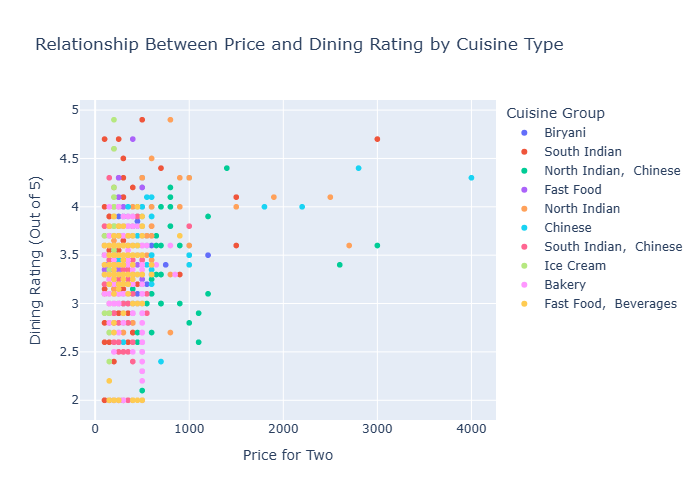

In [50]:
# 3. Generate the interactive scatter plot using Plotly Express
fig = px.scatter(
    scatter_df,
    x='Price for 2',
    y='Dining Rating',
    color='Cuisine',
    title='Relationship Between Price and Dining Rating by Cuisine Type',
    hover_data=['Name of Restaurant', 'Location'],
    color_discrete_sequence=px.colors.qualitative.Plotly,
    opacity=1 # Adds transparency so overlapping data points are easier to see
).update_layout(
    xaxis_title='Price for Two',
    yaxis_title='Dining Rating (Out of 5)',
    legend_title_text='Cuisine Group'
)

fig.show()

***Q9) Is there a relation between Region and Price?***

In [51]:
# Get the list of the top 20 locaations
top_20_locations = zomato_df['Location'].value_counts().head(20).index

#Filter the dataframe for these top 20 areas
region_price_df = zomato_df[zomato_df['Location'].isin(top_20_locations)]

#Calculate the average price 
avg_price_by_region = region_price_df.groupby('Location')['Price for 2'].mean().reset_index()
avg_price_by_region.columns = ['Location', 'Average Price for 2']

# Sort the location
avg_price_by_region = avg_price_by_region.sort_values(by='Average Price for 2', ascending=False)
avg_price_by_region

,Location,Average Price for 2
9,Nungambakkam,497.580645
0,Adyar,443.550000
18,Thuraipakkam,394.340426
2,Anna Nagar,388.656430
16,T. Nagar,375.159236
5,Kilpauk,366.089109
19,Velachery,364.112903
8,Mogappair,363.255814
12,Perungudi,360.590278
7,Medavakkam,355.719557


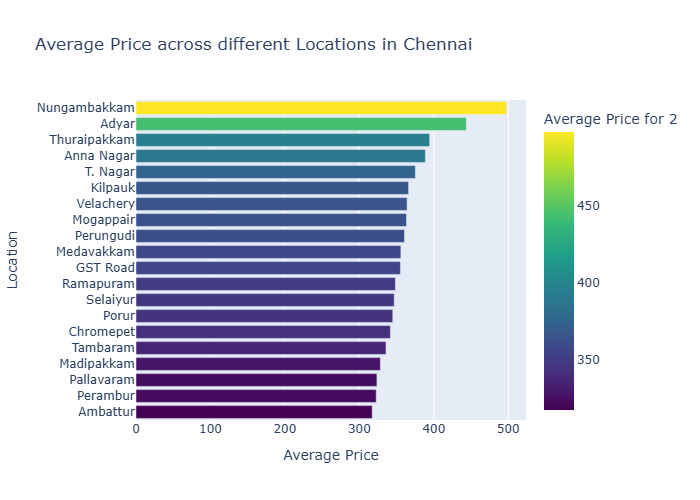

In [52]:
# Create a simple horizontal bar chart showing average price variation
fig = px.bar(
    avg_price_by_region,
    x='Average Price for 2',
    y='Location',
    orientation='h',
    title='Average Price across different Locations in Chennai',
    color='Average Price for 2',
    color_continuous_scale='Viridis'
).update_layout(
    yaxis={'categoryorder':'total ascending'},
    xaxis_title='Average Price',
    yaxis_title='Location'
)

fig.show()

***Q10) Find the list of Affordable Restaurants?***

In [53]:
max_price = zomato_df["Price for 2"].max()
one_fourth_price = max_price/4
one_fourth_price

1250.0

In [54]:
aff_rest_df = zomato_df[['Name of Restaurant','Price for 2','Cuisine','Location']]
aff_rest_df = aff_rest_df[aff_rest_df["Price for 2"]<=1250]
aff_rest_df.sort_values(by="Price for 2",inplace=True)
aff_rest_df

,Name of Restaurant,Price for 2,Cuisine,Location
4685,Soda Hub,40.0,Beverages,"OMR Food Street, Navallur"
6854,Planet Soda,50.0,"Beverages, Juices","OMR Food Street, Kandanchavadi"
7405,Indian Coffee House,50.0,"Beverages, Juices",Vepery
8355,Kaafemaa,50.0,Beverages,Ambattur
1448,Mamee Soup,60.0,Healthy Food,West Mambalam
...,...,...,...,...
541,Yaki BBQ,1200.0,"Biryani, North Indian, BBQ, South Indian",Perungudi
508,Toscano,1200.0,"Italian, Continental, Fast Food",Nungambakkam
152,Pause Bar & Kitchen,1200.0,"Italian, Continental, Chinese, North Indian","OMR Food Street, Kandanchavadi"
45,Pedreno's,1200.0,"Pizza, American, Italian",Mylapore


In [55]:
highrate_rest_df=zomato_df[['Name of Restaurant','Price for 2','Cuisine','Location','Dining Rating']]
highrate_rest_df = highrate_rest_df[highrate_rest_df['Dining Rating']>=4.5]
highrate_rest_df.sort_values(by='Price for 2', inplace=True)
highrate_rest_df

,Name of Restaurant,Price for 2,Cuisine,Location,Dining Rating
108,Rayar's Mess,100.0,South Indian,Mylapore,4.7
178,Royal Sandwich Shop,150.0,"Fast Food, Desserts, Beverages",Alwarpet,4.7
50,Andhikkadai,200.0,South Indian,Velachery,4.6
154,Nair Mess,200.0,"South Indian, Biryani",Triplicane,4.5
320,Bombay Kulfi,200.0,Ice Cream,Adyar,4.9
...,...,...,...,...,...
445,Dakshin - Crowne Plaza Chennai Adyar Park,2500.0,"South Indian, Kerala, Andhra","Crowne Plaza Chennai Adyar Park, Alwarpet",4.6
395,Southern Spice - Taj Coromandel,3000.0,South Indian,"Taj Coromandel, Nungambakkam",4.7
229,Vasco's - Hilton Chennai,3400.0,"North Indian, Continental, Asian","Hilton Chennai, Guindy",4.6
443,Avartana - ITC Grand Chola,4500.0,"South Indian, Chinese, Desserts","ITC Grand Chola, Guindy",4.8


In [56]:
highrate_aff_df= pd.merge(aff_rest_df,highrate_rest_df, how='inner',on=['Name of Restaurant','Location'])
highrate_aff_df= highrate_aff_df[['Name of Restaurant','Price for 2_x','Cuisine_x','Location','Dining Rating']]
highrate_aff_df.rename(columns={'Name of Restaurant':'NAME OF RESTAURANT','Price for 2_x':'PRICE','Cuisine_x':'CUSINE_CATEGORY',
                                'Location':'LOCATION','Dining Rating':'DINING RATING'},inplace=True)
highrate_aff_df

,NAME OF RESTAURANT,PRICE,CUSINE_CATEGORY,LOCATION,DINING RATING
0,Rayar's Mess,100.0,South Indian,Mylapore,4.7
1,Royal Sandwich Shop,150.0,"Fast Food, Desserts, Beverages",Alwarpet,4.7
2,Royal Sandwich Shop,150.0,"Fast Food, Desserts, Beverages",Alwarpet,4.7
3,Royal Sandwich Shop,150.0,"Fast Food, Desserts, Beverages",Alwarpet,4.7
4,Bombay Kulfi,200.0,Ice Cream,Anna Nagar,4.6
5,Bombay Kulfi,200.0,Ice Cream,Adyar,4.9
6,Nair Mess,200.0,"South Indian, Biryani",Triplicane,4.5
7,Andhikkadai,200.0,South Indian,Velachery,4.6
8,Eating Circles,250.0,South Indian,Alwarpet,4.7
9,Welcome Hotel,300.0,"South Indian, Desserts, Beverages",Purasavakkam,4.5
